# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('../Data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [2]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [3]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

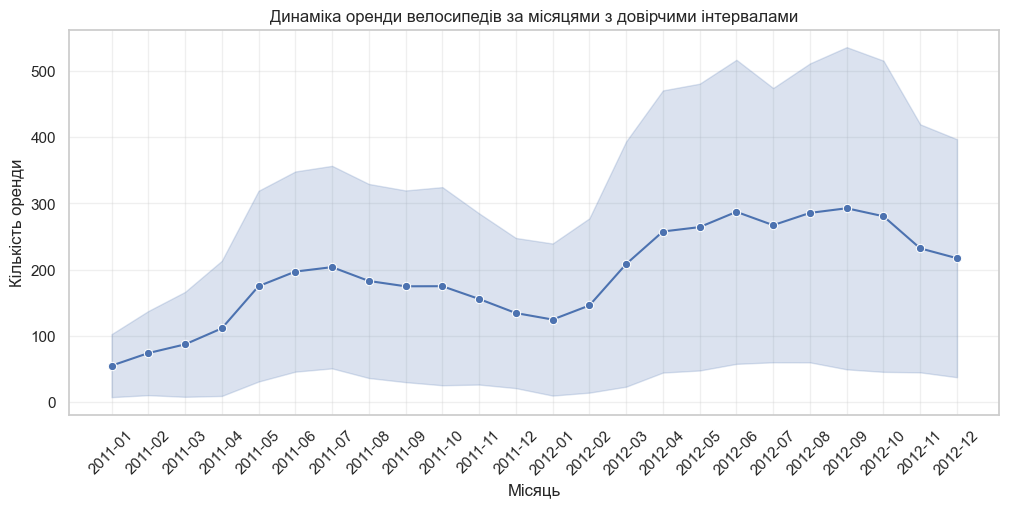

In [4]:
plt.figure(figsize=(12, 5))

sns.lineplot(df,
             x='month_year',
             y='count',
             marker = 'o',
             errorbar='sd'
)

plt.xticks(rotation=45)
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.grid(alpha=0.3);

**Відповідь на питання:**

- Найбільша невизначеність в даних спостерігається з червня по жовтень 2012 року.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

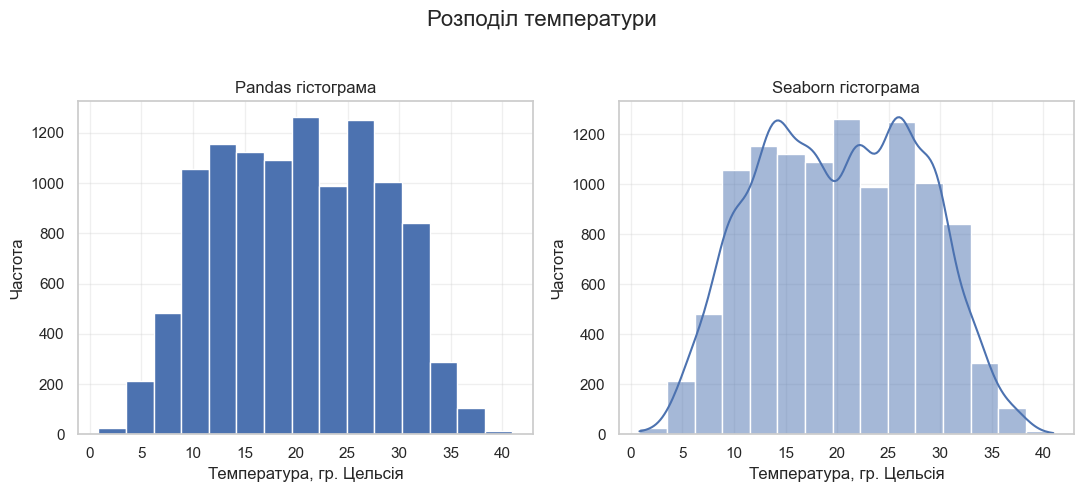

In [5]:
plt.figure(figsize=(11, 5))

plt.subplot(1, 2, 1)
df['temp'].hist(bins=15)
plt.title('Pandas гістограма')
plt.xlabel('Температура, гр. Цельсія')
plt.ylabel('Частота')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(df['temp'], bins=15, kde=True)
plt.title('Seaborn гістограма')
plt.xlabel('Температура, гр. Цельсія')
plt.ylabel('Частота')
plt.grid(alpha=0.3)

plt.suptitle('Розподіл температури', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]);

**Відповіді на питання:**

1. В даному випадку основна візуальна різниця між 2-ма гістограмами полягає у більш м'якому кольорі та наявності плавної кривої поверх гістограми Seaborn.
2. Додаткова лінія на графіку в Seaborn називається KDE (Kernel Density Estimate) — оцінка щільності розподілу. Ця плавна лінія показує загальну форму розподілу даних.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [6]:
def weather_condition(value):
    if value == 1:
        return 'Ясно'
    elif value == 2:
        return 'Туман'
    elif value == 3:
        return 'Легкий дощ'
    else:
        return 'Сильний дощ'

In [7]:
df['weather_condition'] = df['weather'].apply(weather_condition)

In [8]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,...,date,day,week,weekday_num,weekday,year,month,hour,month_year,weather_condition
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,...,2011-01-01,1,52,5,Saturday,2011,1,0,2011-01,Ясно
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,...,2011-01-01,1,52,5,Saturday,2011,1,1,2011-01,Ясно
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,...,2011-01-01,1,52,5,Saturday,2011,1,2,2011-01,Ясно
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,...,2011-01-01,1,52,5,Saturday,2011,1,3,2011-01,Ясно
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,...,2011-01-01,1,52,5,Saturday,2011,1,4,2011-01,Ясно


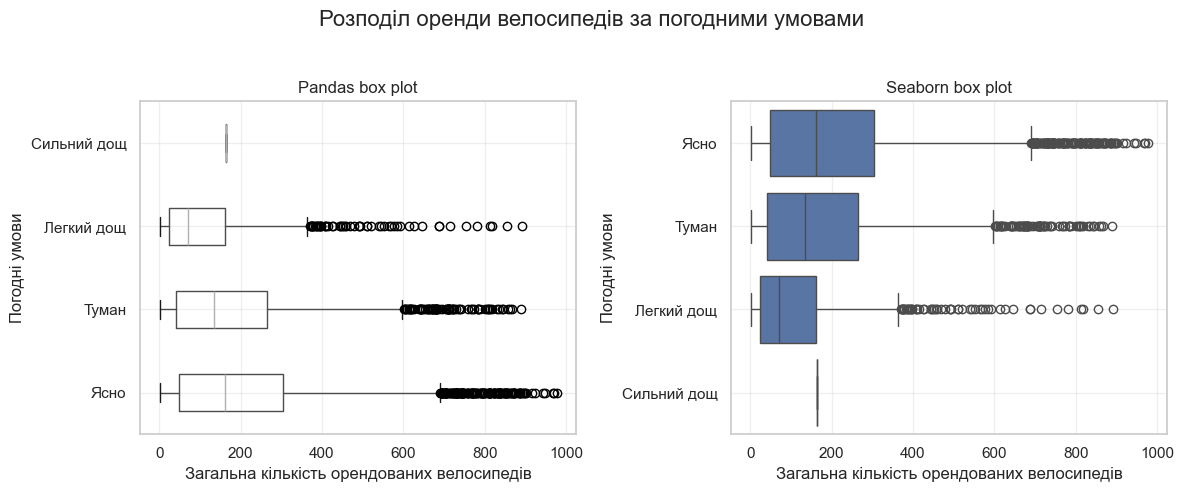

In [9]:
weather_order = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
df['weather_condition'] = pd.Categorical(
    df['weather_condition'],
    categories=weather_order,
    ordered=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column='count', by='weather_condition', vert=False, ax=axes[0])
axes[0].set_title('Pandas box plot')
axes[0].set_xlabel('Загальна кількість орендованих велосипедів')
axes[0].set_ylabel('Погодні умови')
axes[0].grid(alpha=0.3)

sns.boxplot(data=df, x='count', y='weather_condition', order=weather_order, ax=axes[1])
axes[1].set_title('Seaborn box plot')
axes[1].set_xlabel('Загальна кількість орендованих велосипедів')
axes[1].set_ylabel('Погодні умови')
axes[1].grid(alpha=0.3)

plt.suptitle('Розподіл оренди велосипедів за погодними умовами', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]);

**Відповідь на питання:**

- Основна візуальна різниця між 2-ма box plot полягає у порядку розташування погодніх умов та зафарбованих "коробочок".

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [10]:
correlation = df[['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']].corr()

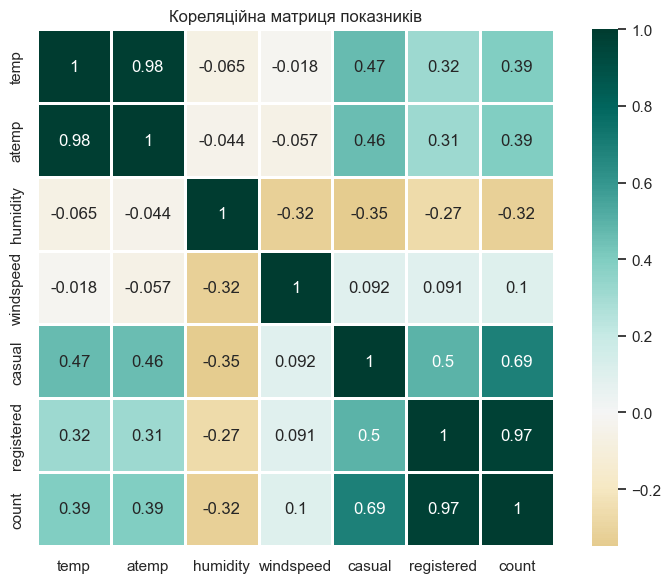

In [11]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation,
            annot=True,
            cmap='BrBG',
            center=0,
            square=True,
            linewidths=0.75
)
plt.title('Кореляційна матриця показників')
plt.tight_layout();

**Відповіді на питання:**

1. З загальною кількістю оренди (`count`) найсильніше корелюють зареєстровані користувачі (`registered`) - 0.97, дещо менше випадкові (`casual`) - 0.69, що є цілком логічним, оскільки `count` = `registered` + `casual`.
2. Між `temp` та `atemp` майже ідеальна позитивна кореляція (0.98), тому що `atemp` розраховується на основі `temp`.
3. Негативну кореляція мають наступні змінні:
- `casual`, `humidity` (-0.35);
- `windspeed`, `humidity` (-0.32);
- `count`, `humidity` (-0.32).

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


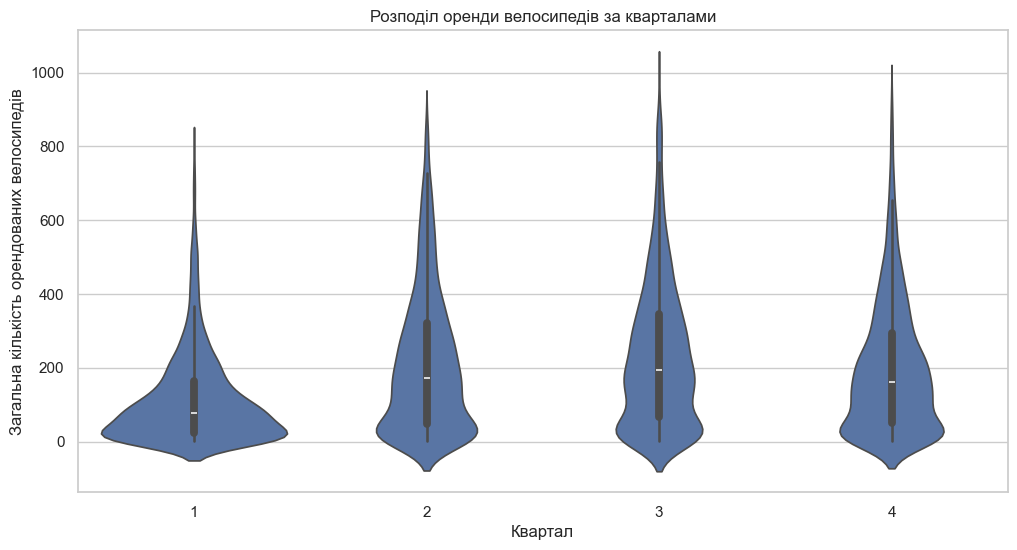

In [12]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df,
               x='season',
               y='count'
)
plt.title('Розподіл оренди велосипедів за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Загальна кількість орендованих велосипедів');

**Відповіді на питання:**

1. "Товщина" violin plot показує щільність розподілу даних.
2. Найбільша варіабельність оренди спостерігається у 3 кварталі.
3. Violin plot показує форму розподілу (чи є кілька піків, асиметрія, скупчення значень), тоді як box plot показує лише 5 числових характеристик (min, Q1, медіана, Q3, max).

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

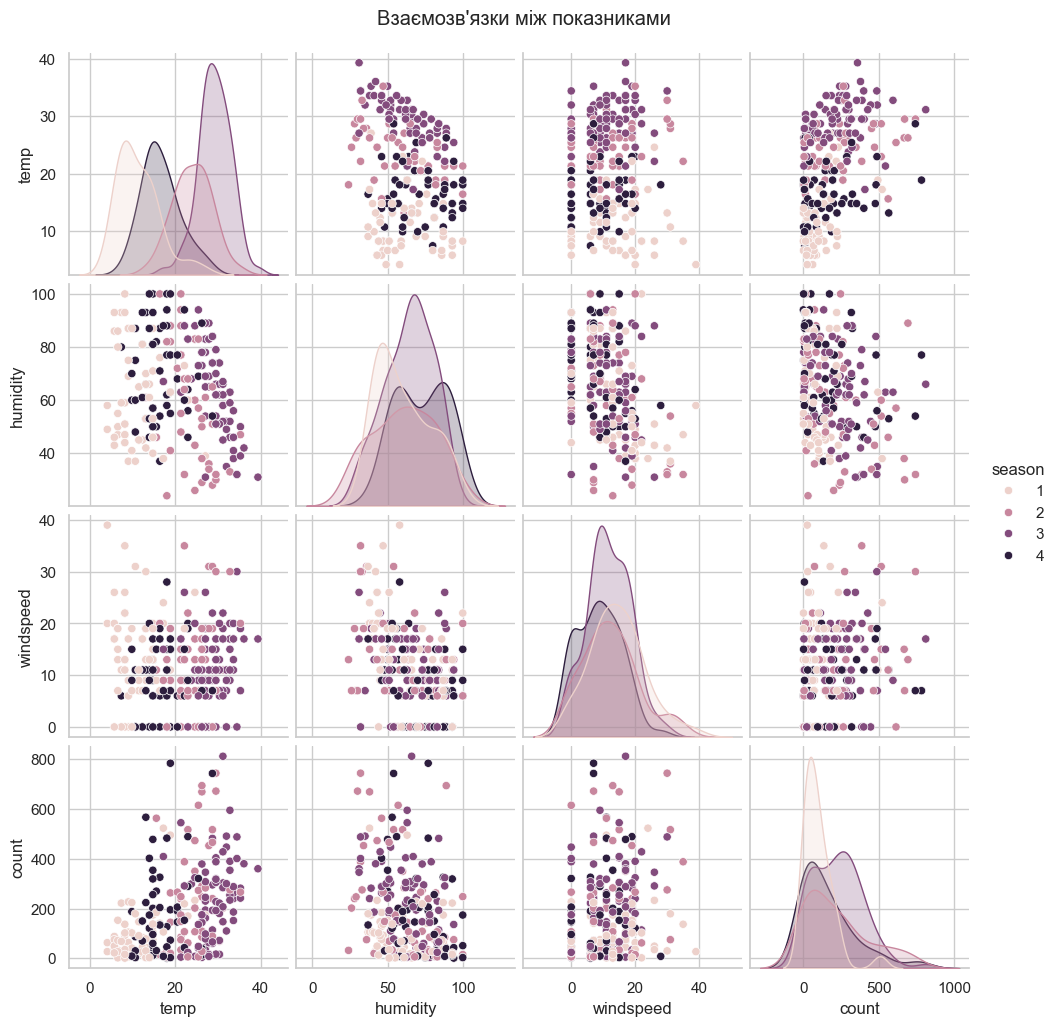

In [13]:
sample_df1 = df[['temp', 'humidity', 'windspeed', 'count', 'season']].sample(250)

sns.pairplot(sample_df1, hue='season')
plt.suptitle("Взаємозв'язки між показниками", y=1.025);

**Відповіді на питання:**

1. Найсильніший лінійний зв'язок спостерігається між `temp` та `count`.
2. Між кварталами найбільше відрізняється `temp`, і як наслідок `count`.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

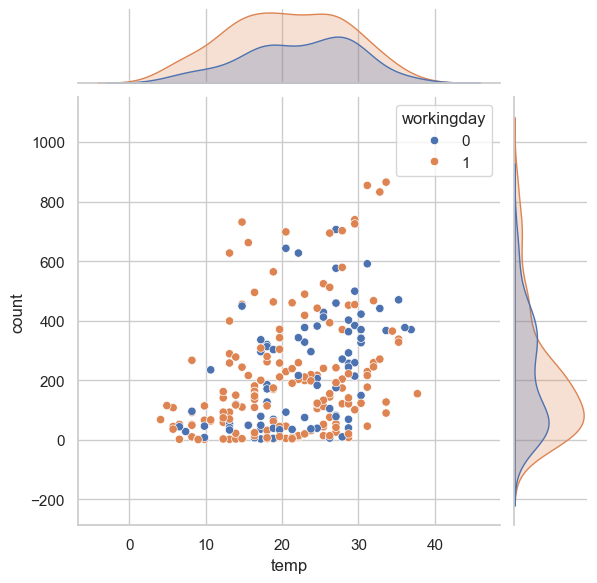

In [14]:
sample_df2 = df[['temp', 'count', 'workingday']].sample(250)

sns.jointplot(data=sample_df2,
              x='temp',
              y='count',
              hue='workingday'
);

**Відповіді на питання:**
1. Графіки на краях показують маргінальні розподіли (KDE-криві).
2. У робочі дні користувачі орендують велосипеди частіше.